## Diabetes Prediction Project (SIS-2)

### 1. Dataset Overview & EDA
###2. Preprocessing
### 3. Model Training
### 4. Model Evaluation
### 5. Discussion & Insights

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [19]:
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,1
Fruits,1


In [4]:
print("Size of the dataset -", df.shape)

Size of the dataset - (35096, 22)


In [5]:
df.shape

(35096, 22)

In [6]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [7]:
df['Diabetes_binary'].value_counts()

,count
Diabetes_binary,
0.0,30418
1.0,4678


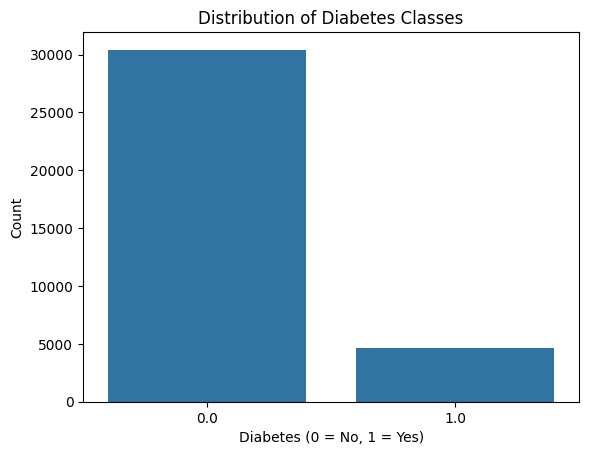

In [8]:
sns.countplot(x='Diabetes_binary', data=df)
plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

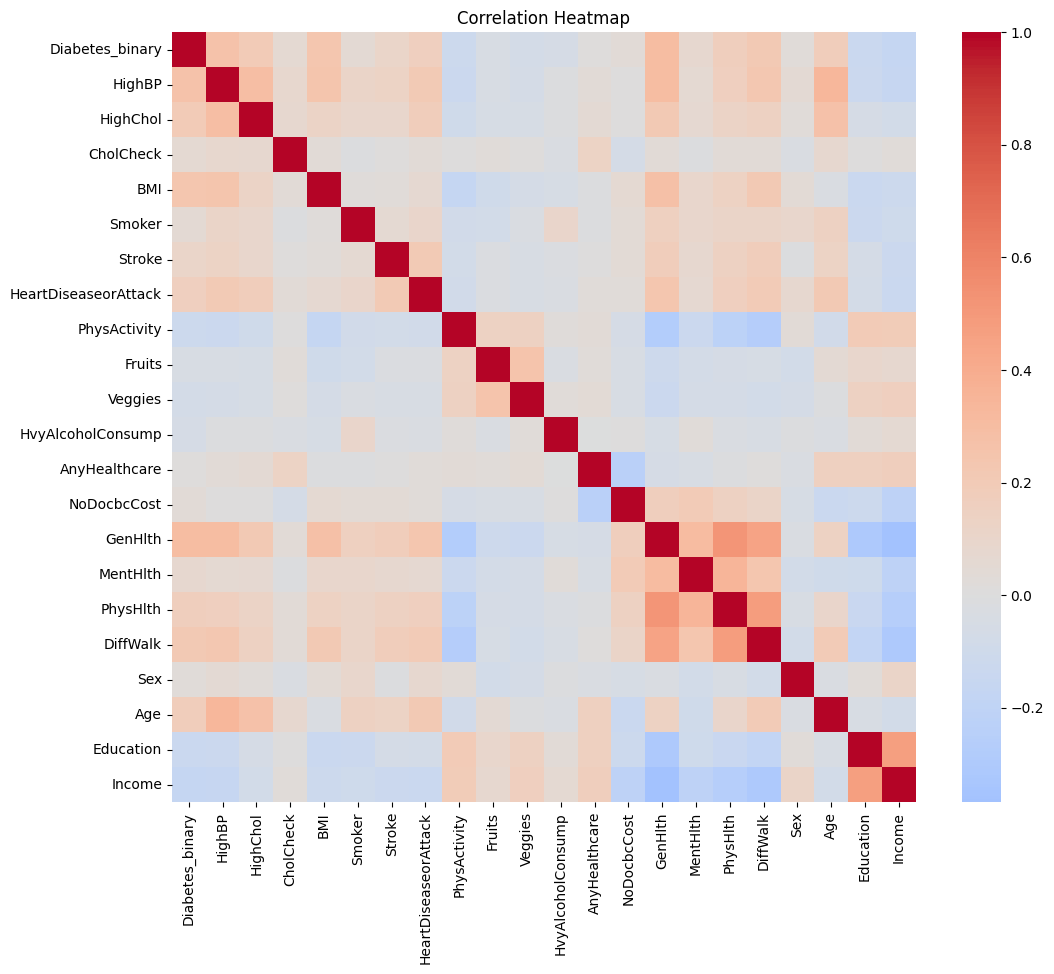

In [9]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [23]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred_log = log_model.predict(X_test_scaled)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8698005698005699
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93      6061
         1.0       0.58      0.16      0.26       959

    accuracy                           0.87      7020
   macro avg       0.73      0.57      0.59      7020
weighted avg       0.84      0.87      0.84      7020



In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [28]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [29]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8652421652421652
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93      6061
         1.0       0.53      0.13      0.21       959

    accuracy                           0.87      7020
   macro avg       0.70      0.56      0.57      7020
weighted avg       0.83      0.87      0.83      7020



In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [31]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [32]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8517094017094017
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92      6061
         1.0       0.41      0.19      0.26       959

    accuracy                           0.85      7020
   macro avg       0.64      0.57      0.59      7020
weighted avg       0.82      0.85      0.83      7020



In [33]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

SVC()

In [34]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [35]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.867948717948718
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93      6061
         1.0       0.62      0.09      0.15       959

    accuracy                           0.87      7020
   macro avg       0.75      0.54      0.54      7020
weighted avg       0.84      0.87      0.82      7020



In [36]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)

array([[5946,  115],
       [ 831,  128]])

In [37]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])

np.float64(0.8218896897874735)

In [38]:
print("Logistic:", accuracy_score(y_test, y_pred_log))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic: 0.8698005698005699
Random Forest: 0.8652421652421652
KNN: 0.8517094017094017
SVM: 0.867948717948718


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# Random Forest
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

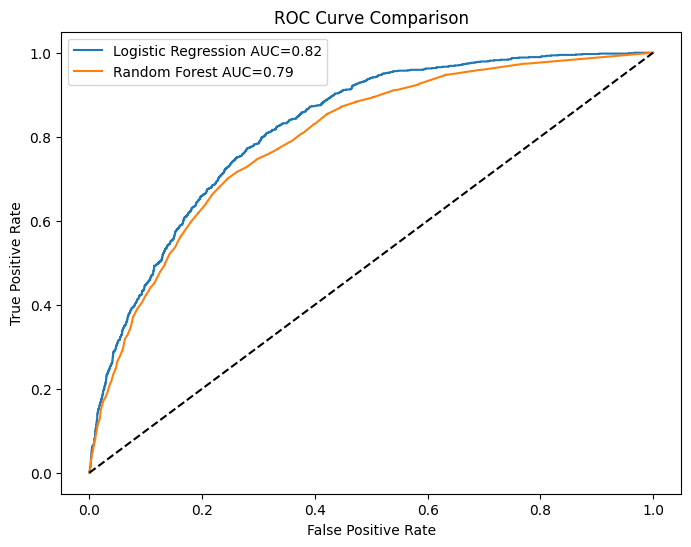

In [40]:
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC={auc_log:.2f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC={auc_rf:.2f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

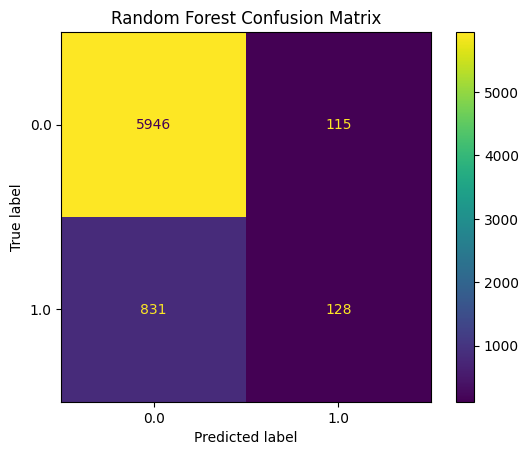

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()